In [1]:
import logging
import sys
import time
from math import ceil

import contextily as ctx
import dask.array as da
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import rasterio
from rasterio import features, windows
from rasterio.transform import from_origin, xy
from rasterio.windows import Window
from scipy.ndimage import distance_transform_edt
from shapely.geometry import LineString, MultiLineString
from shapely.ops import unary_union
from skimage.morphology import medial_axis, skeletonize
from tqdm import tqdm


# ----------------------------------------------------------------------
# Helper: force plain Python ints (prevents TypeError later)
# ----------------------------------------------------------------------
def _as_int(v):
    return int(float(v))


# ----------------------------------------------------------------------
# Logging configuration (feel free to adjust level)
# ----------------------------------------------------------------------
log = logging.getLogger("centerline")
log.setLevel(logging.INFO)  # DEBUG for more chatter
handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(
    logging.Formatter("%(asctime)s %(levelname)-8s %(message)s", "%H:%M:%S")
)
log.addHandler(handler)

log.info("=== START CENTER‑LINE PIPELINE (no labeling) ===")
t_start = time.time()


%matplotlib widget

10:39:38 INFO     === START CENTER‑LINE PIPELINE (no labeling) ===


In [2]:
gdf = gpd.read_parquet("../data/streets/streets_DE_depth2.parquet")
gdf = gdf.set_crs(epsg=4326)
gdf.head()

FileNotFoundError: [Errno 2] Failed to open local file '../data/streets/streets_DE_depth2.parquet'. Detail: [errno 2] No such file or directory

In [ ]:
gdf = gdf.to_crs(epsg=3035) 

In [ ]:
BUFFER_DIST = 100 # in meters

gdf.geometry = gdf.geometry.apply(lambda line: line.buffer(BUFFER_DIST))
merged_buffers = gpd.GeoDataFrame(geometry=[unary_union(gdf.geometry)], crs=gdf.crs)

In [ ]:
# Split Multipolygons into individual Polygons if they are not touching
#merged_buffers = merged_buffers.explode(index_parts=False).reset_index(drop=True)

In [ ]:
def tiled_reader(path, tile_size=1024, overlap=1):
    """
    Generator yielding (window, skeleton_tile, dist_tile, row_offset, col_offset)
    """
    with rasterio.open(path) as src:
        height, width = src.height, src.width

        # Read the distance transform once (you can also stream it similarly)
        # If you already have a separate distance raster, open it the same way.
        dist = src.read(1)                     # whole distance band – optional
        # If dist is too big, you can also read it tile‑wise in the loop below.

        for row in range(0, height, tile_size):
            for col in range(0, width, tile_size):
                # Compute window extents with overlap
                win = Window(
                    col_off=max(col - overlap, 0),
                    row_off=max(row - overlap, 0),
                    width=min(tile_size + 2 * overlap, width - col + overlap),
                    height=min(tile_size + 2 * overlap, height - row + overlap),
                )
                # Clip to raster bounds
                win = win.intersection(Window(0, 0, width, height))

                # Load the binary mask (skeleton) for this window
                # Assuming the skeleton is stored in a separate band/file.
                # Replace `'skeleton.tif'` with your actual skeleton raster.
                with rasterio.open('skeleton.tif') as sk_src:
                    sk_tile = sk_src.read(1, window=win)

                # Slice the distance array to the same window
                dist_tile = dist[
                    int(win.row_off) : int(win.row_off + win.height),
                    int(win.col_off) : int(win.col_off + win.width),
                ]

                yield (
                    win,
                    sk_tile.astype(bool),   # ensure boolean mask
                    dist_tile,
                    int(win.row_off),       # global row offset of the tile's origin
                    int(win.col_off),       # global col offset of the tile's origin
                )

In [ ]:
def skeleton_to_weighted_graph(skel, dist):
    G = nx.Graph()
    rows, cols = np.where(skel)
    for r, c in zip(rows, cols):
        G.add_node((r, c), weight=dist[r, c])
        # 8‑neighbour offsets
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if 0 <= nr < skel.shape[0] and 0 <= nc < skel.shape[1] and skel[nr, nc]:
                    # Edge weight = negative average distance (so Dijkstra prefers high distance)
                    w = - (dist[r, c] + dist[nr, nc]) / 2.0
                    G.add_edge((r, c), (nr, nc), weight=w)
    return G

def skeleton_to_positive_graph(skel, dist):
    """
    Returns a NetworkX Graph where each edge weight is:
        cost = max_dist - average_distance_of_the_two_pixels
    This way, paths that go through more central pixels (higher distance to edge)
    have lower cost and are preferred by shortest-path algorithms.
    8-connectivity is used (including diagonals).
    """
    G = nx.Graph()
    rows, cols = np.where(skel)
    max_dist = float(dist.max())               # biggest distance in the whole mask

    for r, c in zip(rows, cols):
        G.add_node((r, c), dist=dist[r, c])

        # 8‑connectivity (including diagonals)
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if (0 <= nr < skel.shape[0] and
                    0 <= nc < skel.shape[1] and
                    skel[nr, nc]):
                    # Average distance of the two neighbouring pixels
                    avg = (dist[r, c] + dist[nr, nc]) / 2.0
                    # Larger avg → cheaper (more central)
                    cost = max_dist - avg
                    G.add_edge((r, c), (nr, nc), weight=cost)
    return G

def skeleton_to_positive_graph_tile(skel, dist, row_off=0, col_off=0):
    """
    Build a graph for a single tile.
    `row_off` / `col_off` are the global offsets of the tile's top‑left corner.
    """
    G = nx.Graph()
    rows, cols = np.where(skel)
    max_dist = float(dist.max())

    for r, c in zip(rows, cols):
        # Translate tile‑local (r,c) → global (R,C)
        R, C = r + row_off, c + col_off
        G.add_node((R, C), dist=dist[r, c])

        # 8‑connectivity (including diagonals)
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                # Stay inside the tile (no need to check global bounds here)
                if (0 <= nr < skel.shape[0] and
                    0 <= nc < skel.shape[1] and
                    skel[nr, nc]):
                    avg = (dist[r, c] + dist[nr, nc]) / 2.0
                    cost = max_dist - avg
                    # Global neighbour coordinates:
                    N_R, N_C = nr + row_off, nc + col_off
                    G.add_edge((R, C), (N_R, N_C), weight=cost)
    return G

In [ ]:
from shapely.geometry import LineString, MultiLineString


def graph_to_lines(g, pos):
    """Return a MultiLineString representing all edges."""
    lines = []
    for u, v in g.edges():
        # Grab the coordinates of the two endpoints
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        lines.append(LineString([(x1, y1), (x2, y2)]))
    return MultiLineString(lines)

In [ ]:
skel_parts = []
dist_parts = []
pixel_size = 10
global_graph = nx.Graph()
tile_size = 16384  # process in 16k×16k pixel tiles

for idx, feature in merged_buffers.iterrows():
    geom = feature.geometry
    bounds = geom.bounds  # minx, miny, maxx, maxy
    log.debug(f"Feature {idx}: bounds = {bounds}")

    minx, miny, maxx, maxy = bounds
    width = _as_int((maxx - minx) / pixel_size)
      
    # Create a raster covering the bounding box of the geometry
    height = _as_int((maxy - miny) / pixel_size)
    transform = from_origin(minx, maxy, pixel_size, pixel_size)
    log.info(f"Raster grid: {width:,} x {height:,} pixels @ {pixel_size} units/pixel")

    profile = {
        "driver": "GTiff",
        "dtype": "uint8",
        "count": 1,
        "height": height,
        "width": width,
        "crs": gdf.crs,
        "transform": transform,
        "compress": "deflate",
    }

    total_tiles_x = (width + tile_size - 1) // tile_size
    total_tiles_y = (height + tile_size - 1) // tile_size
    total_tiles = total_tiles_x * total_tiles_y
    log.info(
        f"Processing in {total_tiles} tiles of size {tile_size}×{tile_size} pixels"
    )

    with rasterio.MemoryFile() as mem:
        with mem.open(**profile) as dst:
            log.info("Rasterising polygon (tile-wise)…")
            with tqdm(total=total_tiles, desc="Write tiles", unit="tile") as prog:
                for row_off in range(0, height, tile_size):
                    for col_off in range(0, width, tile_size):
                        win = windows.Window(
                            col_off,  # type: ignore
                            row_off,
                            min(tile_size, width - col_off),
                            min(tile_size, height - row_off),
                        )
                        mask = features.rasterize(
                            [(geom, 1)],
                            out_shape=(int(win.height), int(win.width)),
                            transform=dst.window_transform(win),
                            fill=0,
                            dtype="uint8",
                        )
                        dst.write(mask, 1, window=win)
                        prog.update(1)

        # ------------------------------------------------------------------
        # Lazy skeletonisation (still tile‑wise, never loads full raster)
        # ------------------------------------------------------------------
        log.info("Opening raster for lazy skeletonisation …")
        with mem.open() as src:
            dask_arr = da.from_array(src.read(1), chunks=(tile_size, tile_size))  # type: ignore

            def skel_block(arr):
                """Thin the binary mask to a 1‑pixel wide skeleton."""
                return medial_axis(arr.astype(bool), return_distance=False)

            skeleton = da.map_blocks(
                skel_block, dask_arr, dtype=np.uint8
            )

        log.info("Writing skeleton raster (tile‑wise)…")
        with rasterio.MemoryFile() as ske_mem:
            with ske_mem.open(**profile) as ske_dst:
                with tqdm(
                    total=total_tiles, desc="Skeleton tiles", unit="tile"
                ) as prog:
                    for row_off in range(0, height, tile_size):
                        for col_off in range(0, width, tile_size):
                            win = windows.Window(
                                col_off,  # type: ignore
                                row_off,
                                min(tile_size, width - col_off),
                                min(tile_size, height - row_off),
                            )
                            block = skeleton[
                                row_off : row_off + int(win.height),
                                col_off : col_off + int(win.width),
                            ].compute()
                            
                            dist = distance_transform_edt(block > 0)
                            G_tile = skeleton_to_positive_graph_tile(
                                block,
                                dist,
                                row_off=_as_int(win.row_off),
                                col_off=_as_int(win.col_off),
                            )

                            global_graph.add_edges_from(G_tile.edges(data=True))
                            global_graph.add_nodes_from(G_tile.nodes(data=True))
                            prog.update(1)

17:15:59 INFO     Raster grid: 63,914 x 81,474 pixels @ 10 units/pixel
17:15:59 INFO     Processing in 20 tiles of size 16384×16384 pixels
17:15:59 INFO     Rasterising polygon (tile-wise)…


Write tiles: 100%|██████████| 20/20 [06:23<00:00, 19.18s/tile]

17:22:28 INFO     Opening raster for lazy skeletonisation …


17:22:36 INFO     Writing skeleton raster (tile‑wise)…


Skeleton tiles: 100%|██████████| 20/20 [17:51<00:00, 53.57s/tile]


In [ ]:
# print number of nodes and edges
log.info(f"Graph has {global_graph.number_of_nodes():,} nodes and {global_graph.number_of_edges():,} edges")

17:40:28 INFO     Graph has 1,690,128 nodes and 1,692,435 edges


In [ ]:
def pixel_to_world(row, col, transform=transform):
    """Apply the raster affine transform."""
    x, y = transform * (col, row)
    return x, y

def graph_to_geometries(G: nx.Graph, transform):
    """
    Returns a GeoDataFrame with a single MultiLineString geometry
    that represents every edge of the graph, correctly georeferenced.
    """
    lines = []
    for u, v, _ in G.edges(data=True):
        # u and v are (row, col) tuples
        x1, y1 = pixel_to_world(u[0], u[1], transform)
        x2, y2 = pixel_to_world(v[0], v[1], transform)
        lines.append(LineString([(x1, y1), (x2, y2)]))

    mls = MultiLineString(lines)

    # If you know the CRS (e.g., EPSG:32633), set it here.
    # Replace with the actual CRS of your raster.
    crs = "EPSG:3035"          # <-- adjust as needed
    gdf = gpd.GeoDataFrame({"geometry": [mls]}, crs=crs)
    return gdf

In [ ]:
# print number of nodes and edges
log.info(f"Graph has {global_graph.number_of_nodes():,} nodes and {global_graph.number_of_edges():,} edges")

19:03:42 INFO     Graph has 0 nodes and 0 edges


In [ ]:
gdf_edges_smoothed = gdf_edges.simplify(tolerance=50, preserve_topology=True)

/tmp/ipykernel_7025/4272846216.py:6: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


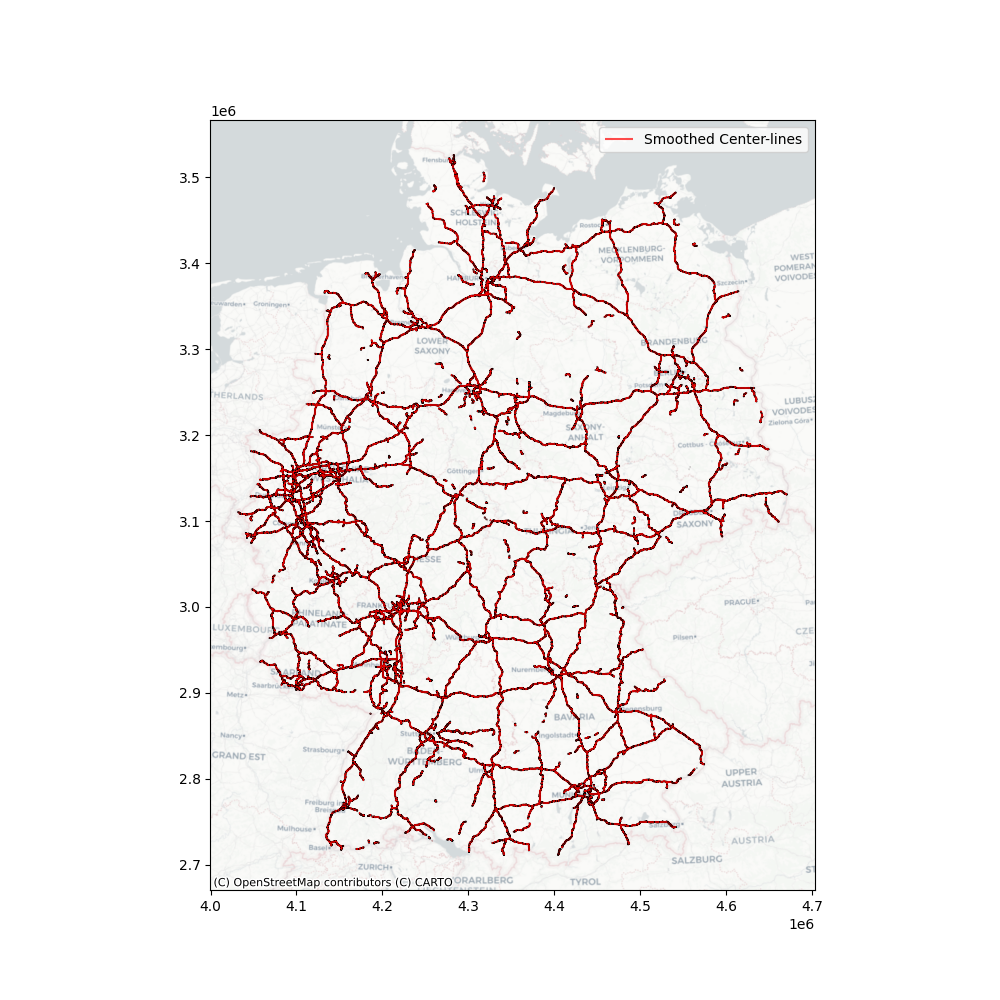

In [ ]:
# plot original lines and centerlines on the same map
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, alpha=0.5, edgecolor="k", label="Original Buffers")
gdf_edges_smoothed.plot(ax=ax, alpha=0.7, edgecolor="red", label="Smoothed Center-lines")
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.CartoDB.Positron)
plt.legend()
plt.show()

In [ ]:
# export to geojson
#gdf_edges_smoothed.to_file("../data/streets/streets_DE_centerlines.geojson", driver="GeoJSON")
gdf_edges_smoothed.to_parquet("../data/streets/streets_DE_centerlines.parquet")
log.info("=== END CENTER‑LINE PIPELINE ===")

17:42:01 INFO     === END CENTER‑LINE PIPELINE ===


In [ ]:
gdf_streets = gpd.read_parquet("../data/streets/streets_DE_centerlines.parquet")

In [ ]:
gdf_streets_exp = gdf_streets.explode()

In [ ]:
gdf_streets_exp.describe()

,geometry
count,1692435
unique,1692435
top,LINESTRING (4191837.888216469 3389905.92570049...
freq,1


In [ ]:
# get a point every 1000 meters along each linestring
def get_points_along_line(line, distance):
    points = []
    length = line.length
    num_points = int(length // distance)
    for i in range(num_points + 1):
        point = line.interpolate(i * distance)
        points.append(point)
    return points

In [ ]:
points = gdf_streets_exp.geometry.apply(lambda line: get_points_along_line(line, 1000))

In [ ]:
gdf_points = gpd.GeoDataFrame(
    geometry=[pt for sublist in points for pt in sublist], crs=gdf_streets_exp.crs
)
gdf_points.head()

,geometry
0,POINT (4191707.888 3390165.926)
1,POINT (4191707.888 3390155.926)
2,POINT (4191717.888 3390145.926)
3,POINT (4191727.888 3390135.926)
4,POINT (4191727.888 3390125.926)


In [ ]:
gdf_square_cutouts = gpd.GeoDataFrame(
    geometry=gdf_points.geometry.apply(lambda pt: pt.buffer(640).envelope), crs=gdf_points.crs
)

In [ ]:
gdf_square_cutouts.loc[:10].plot()
ctx.add_basemap(
    plt.gca(),
    crs=gdf_square_cutouts.crs.to_string(),
    source=ctx.providers.CartoDB.Positron,
)